In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np
import seaborn as sns
import prince


# Exploratory Data Analysis
## Jeu de données **Politbarometer** (Allemagne)
### Visualisation des données

In [27]:
df = pd.read_stata('../../data/Politbarometer/dataset_cumul_1977.dta',convert_categoricals=False)

/tmp/ipykernel_6803/3844557572.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['CDU' 'SPD' 'CDU' ... 38 99 'CDU']' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  votes_partie_df.loc[:,'v6'] = votes_partie_df['v6'].apply(lambda x: partie_codes[x] if x in partie_codes.keys() else x)


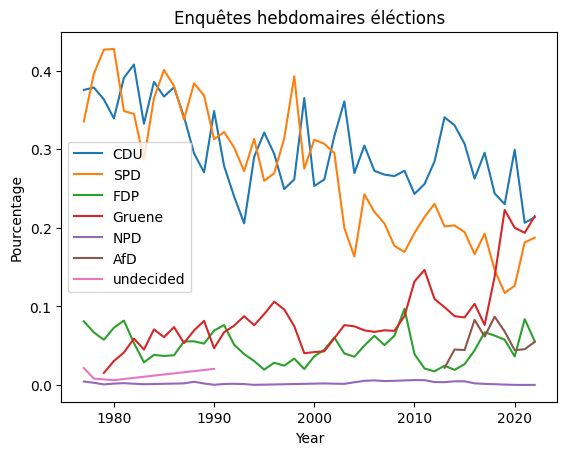

In [28]:
partie_codes = {
    1  : 'CDU',
    2  : 'SPD',
    3  : 'FDP',
    4  : 'Gruene',
    8  : 'NPD',
    49 : 'AfD',
    97 : 'undecided'
}

votes_partie_df = df[['v4', 'v6']]
votes_partie_df.loc[:,'v6'] = votes_partie_df['v6'].apply(lambda x: partie_codes[x] if x in partie_codes.keys() else x)

total_votes_per_year = pd.DataFrame(votes_partie_df.groupby(by=['v4']).size())

total_votes_per_year = total_votes_per_year.reset_index()
votes_partie_df = pd.DataFrame(votes_partie_df.groupby(by=['v4','v6']).size())

votes_partie_df = votes_partie_df.reset_index()
#votes_partie_df[0] = votes_partie_df[0] / total_votes_per_year[0]
votes_partie_df = votes_partie_df.set_index('v4')
total_votes_per_year = total_votes_per_year.set_index('v4')
votes_partie_df['total'] =  total_votes_per_year
votes_partie_df['vote percentage'] = votes_partie_df[0] / votes_partie_df['total']
votes_partie_df = votes_partie_df.query(f'v6 in {list(partie_codes.values())}' )
for partie in partie_codes.values():
    votes_partie_df[votes_partie_df['v6'] == partie]['vote percentage'].plot(label=partie)
plt.xlabel('Year')
plt.ylabel('Pourcentage')
plt.title('Enquêtes hebdomaires éléctions')
plt.legend()
plt.show()

## Data Cleaning
### Remove columns with mostly zero values

In [29]:
df = df[df['v4'] >= 2000]
df


,v1,v2,Version,doi,v3,v4,V4a,v5,v6,v7,...,v72,v73,v74,v75,v76,v77,v78,v79,v80,V81
345603,2391,2001.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,1,1,...,2,1,4,12,0,8,0.520,0,1,0.144
345604,2391,2002.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,2,2,...,10,0,4,12,0,8,0.550,0,1,0.153
345605,2391,2003.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,18,2,...,10,0,1,12,0,8,1.000,0,1,0.277
345606,2391,2004.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,4,99,23,...,10,0,4,12,0,8,1.200,0,1,0.333
345607,2391,2011.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,6,6,...,8,2,4,17,0,7,0.640,0,1,0.178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046814,2391,501626.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,10,0,4,3,0,4,0.383,0,50,0.383
1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,6,2,3,1,0,1,0.596,0,50,0.596
1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,22,...,10,0,4,13,0,5,1.969,0,50,0.954
1046817,2391,501629.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,4,99,23,...,10,0,4,14,0,4,1.038,0,50,0.503


In [30]:
b = (df == 0).astype(int).sum(axis=0) / len(df)
exclure_colonnes = b < 0.8
exclure_colonnes = exclure_colonnes[exclure_colonnes].index
df = df[exclure_colonnes]

# also drop column v63 (answer code 9 : no answer)
df = df.drop(columns=['v63'])

### Remove lines with mostly zero values

In [31]:
valeurs_reponse_refuse = [0,99,999]
compte_par_ligne = df.isin(valeurs_reponse_refuse).sum(axis=1)
compte_par_ligne = compte_par_ligne < 10
print(sum(compte_par_ligne))
df['refuse_inf_a_10_q'] = compte_par_ligne
df = df[compte_par_ligne].drop(columns=['refuse_inf_a_10_q'])

df.to_stata('../../data/Politbarometer/dataset_cumul_1977_reduced.dta')


568024


In [32]:
keywords_fr = {
    1: "Retraite",
    5: "Inflation",
    10: "Impôts",
    13: "Économie",
    14: "Chômage",
    15: "Environnement",
    19: "Famille",
    20: "Système de santé",
    23: "Sécurité intérieure",
    27: "Affaires politiques",
    30: "Éducation",
    53: "Asile",
    54: "Immigration",
    55: "Crise de l'UE",
    56: "Dette publique",
    58: "Extrémisme de droite",
    66: "Autres",
    77: "Inégalités sociales",
    117: "Crise financière",
    134: "Coronavirus",
}

### Réduction de dimension

In [33]:
famd = prince.FAMD(
    n_components=10,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
)
famd = famd.fit(df.head(int(1e4)))

In [34]:
famd.eigenvalues_summary.head(20)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,141.398,1.46%,1.46%
1,134.946,1.40%,2.86%
2,121.508,1.26%,4.12%
3,118.818,1.23%,5.35%
4,111.781,1.16%,6.51%
5,110.964,1.15%,7.66%
6,93.071,0.96%,8.62%
7,90.751,0.94%,9.56%
8,86.455,0.90%,10.46%


## Jeu de données des articles scrappés

In [35]:
first = True
base_path = '../../data/ScrappingJournaux/de'
for file in os.listdir(base_path):
    with open(os.path.join(base_path,file), 'rb') as f:
        answer_code = keywords_fr[int(re.findall('^\d+',file)[0])]
        df = pd.read_pickle(f)
        if first:
            dfs_faz_all = pd.DataFrame(df['faz'].copy())
            dfs_faz_all = dfs_faz_all.rename(columns={'faz':answer_code})
            dfs_taz_all = pd.DataFrame(df['taz'].copy())
            dfs_taz_all = dfs_faz_all.rename(columns={'taz':answer_code})
            first = False
        else:
            dfs_faz_all[answer_code] = df['faz']
            dfs_taz_all[answer_code] = df['taz']

# normalize
#dfs_faz_all = (dfs_faz_all-dfs_faz_all.min())/(dfs_faz_all.max()-dfs_faz_all.min())

#dfs_taz_all = (dfs_taz_all-dfs_taz_all.min())/(dfs_taz_all.max()-dfs_taz_all.min())
#dfs_faz_all = dfs_faz_all.reset_index()

In [36]:
dfs_faz_all

,Crise de l'UE,Éducation,Dette publique,Économie,Sécurité intérieure,Système de santé,Crise financière,Impôts,Affaires politiques,Retraite,Famille,Chômage,Coronavirus,Inflation,Inégalités sociales,Immigration,Extrémisme de droite,Environnement,Asile
Year,,,,,,,,,,,,,,,,,,,
2000,1073,13645,125,1038,1478,350,251,6151,916,1206,34,3768,0,6103,2698,2864,477,1830,1028
2001,2387,15697,158,1391,2144,560,560,7827,2780,1069,48,4837,0,7748,3209,2922,337,2154,1054
2002,4184,15984,231,1502,1977,656,561,7613,731,1113,48,5486,0,7335,2728,2336,693,1700,607
2003,3483,12218,187,1888,1171,670,333,6073,404,1220,32,4196,35,5859,2314,1717,230,1286,463
2004,2674,12601,177,2081,1225,544,233,5868,437,1176,27,4349,5,5796,2301,2172,705,1286,517
2005,1389,13953,602,1863,5506,669,202,6578,538,1136,56,5113,0,6466,2819,3399,1011,1273,538
2006,1007,13999,504,1725,5770,1254,175,6427,437,660,65,4344,1,2631,2715,6534,918,2516,598
2007,917,14084,433,1657,6217,920,819,5590,401,619,32,3598,0,2404,2527,5526,1029,8798,468
2008,1620,14692,529,2577,657,690,6086,5731,289,894,13,3745,0,3315,2637,5416,908,404,493


In [37]:
print(dfs_taz_all.info())
print(dfs_taz_all.head())

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 2000 to 2024
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Crise de l'UE         25 non-null     int64
 1   Éducation             25 non-null     int64
 2   Dette publique        25 non-null     int64
 3   Économie              25 non-null     int64
 4   Sécurité intérieure   25 non-null     int64
 5   Système de santé      25 non-null     int64
 6   Crise financière      25 non-null     int64
 7   Impôts                25 non-null     int64
 8   Affaires politiques   25 non-null     int64
 9   Retraite              25 non-null     int64
 10  Famille               25 non-null     int64
 11  Chômage               25 non-null     int64
 12  Coronavirus           25 non-null     int64
 13  Inflation             25 non-null     int64
 14  Inégalités sociales   25 non-null     int64
 15  Immigration           25 non-null     int64
 16  Extrémisme

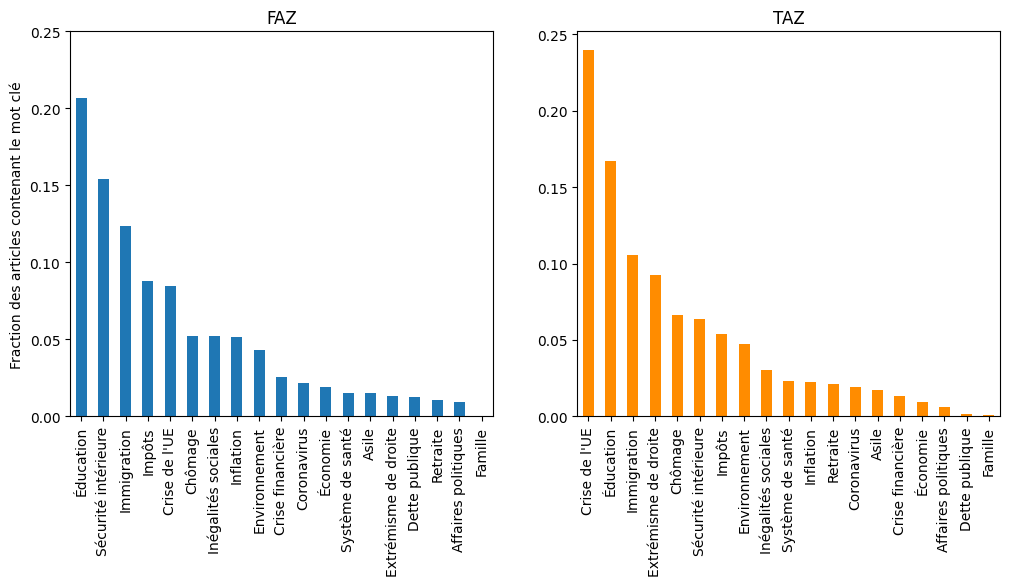

In [38]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12,5))
axs = axs.flatten()

dfs_faz_all_sum = dfs_faz_all.sum()
dfs_faz_all_sum = dfs_faz_all_sum/dfs_faz_all_sum.sum()
dfs_taz_all_sum = dfs_taz_all.sum()
dfs_taz_all_sum = dfs_taz_all_sum/dfs_taz_all_sum.sum()

dfs_faz_all_sum.sort_values(ascending=False).plot(ax=axs[0], kind='bar', title='FAZ')
dfs_taz_all_sum.sort_values(ascending=False).plot(ax=axs[1],kind='bar', title='TAZ',color='darkorange')
axs[0].set_ylabel("Fraction des articles contenant le mot clé")
axs[0].set_ylim(0,0.25)
plt.savefig('../../report/images/apercu_articles_nombre.pdf', bbox_inches='tight')
plt.show()

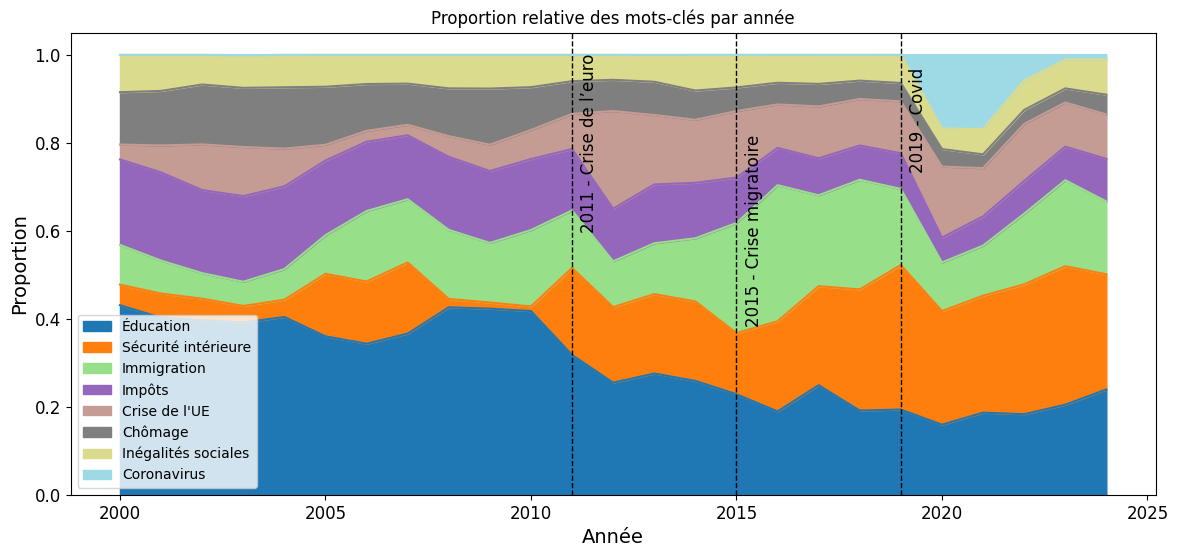

In [39]:
top_5_faz = list(dfs_faz_all_sum.sort_values(ascending=False).index[:7])
top_5_faz.append('Coronavirus')
top_5_taz = dfs_taz_all_sum.sort_values(ascending=False).index
df_rel = dfs_faz_all[top_5_faz].copy()
df_rel = df_rel.div(df_rel.sum(axis=1), axis=0)
df_rel.plot.area(figsize=(14, 6), title="Proportion relative des mots-clés par année",fontsize=16, colormap='tab20')
# Ajouter des annotations
plt.axvline(x=2011, color='black', linestyle='--', linewidth=1)
plt.text(2011 + 0.2, 0.8, '2011 - Crise de l’euro', rotation=90, verticalalignment='center',fontsize=12)

plt.axvline(x=2015, color='black', linestyle='--', linewidth=1)
plt.text(2015 + 0.2, 0.6, '2015 - Crise migratoire', rotation=90, verticalalignment='center',fontsize=12)

plt.axvline(x=2019, color='black', linestyle='--', linewidth=1)
plt.text(2019 + 0.2, 0.85, '2019 - Covid', rotation=90, verticalalignment='center',fontsize=12)
plt.xlabel('Année', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('../../report/images/proportion_relative_faz.pdf',bbox_inches ='tight')
plt.show()

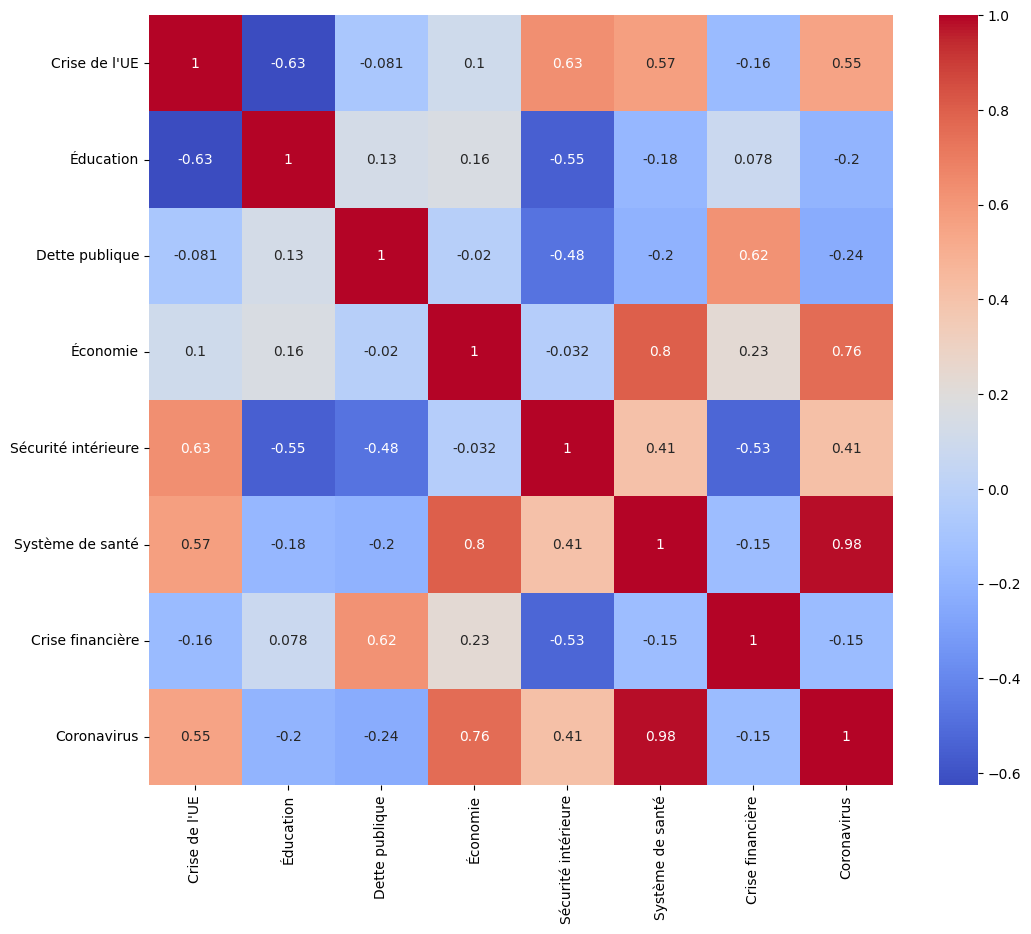

In [40]:
top_5_faz = list(dfs_taz_all_sum.index[:7]) 
top_5_faz.append('Coronavirus')
plt.figure(figsize=(12, 10))  # Taille du graphique
corr = dfs_taz_all[top_5_faz].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig('../../report/images/correlation_taz.pdf',bbox_inches='tight')
plt.show()
